In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re

## Figure 1 code

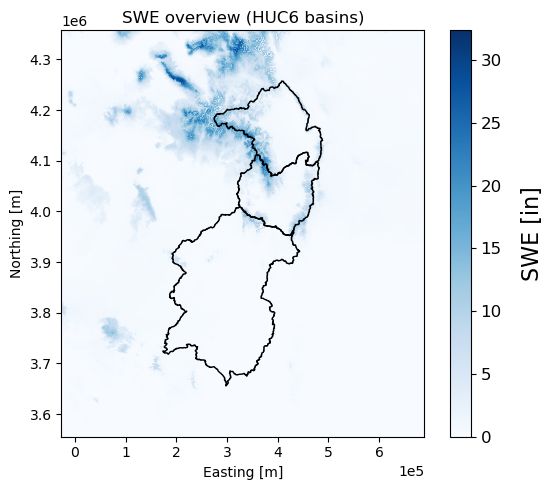

In [2]:
# Read data, reproject to UTM Zone 13N
snodas = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_20230216.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000)
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
# Subset HUC6 for visualization, clip SWE data
huc6_viz = huc6.loc[huc6['Name'].isin(['Rio Grande Headwaters','Upper Rio Grande','Rio Grande-Elephant Butte'])]
bounds = huc6_viz.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

# Plot
fig, ax = plt.subplots(figsize=(6,5))
snodas_clip.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc6_viz.plot(ax=ax, facecolor='none', edgecolor='k')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('SWE overview (HUC6 basins)')
plt.tight_layout()

## Plot for developing DEM

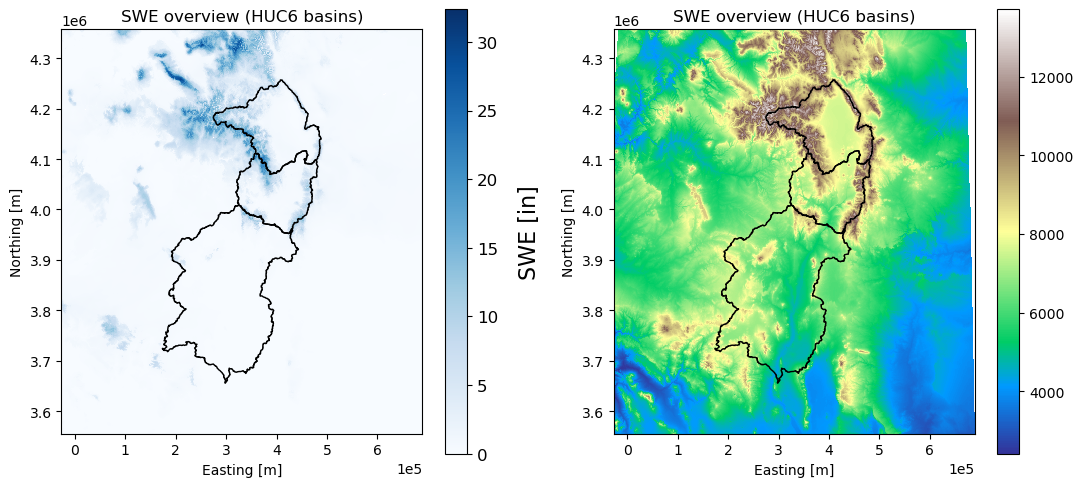

In [3]:
snodas = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_20230216.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000)
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
# Subset HUC6 for visualization, clip SWE data
huc6_viz = huc6.loc[huc6['Name'].isin(['Rio Grande Headwaters','Upper Rio Grande','Rio Grande-Elephant Butte'])]
bounds = huc6_viz.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

dem = rxr.open_rasterio('../data/dem.tif').sel(band=1).reset_coords('band', drop=True)
dem = dem.where(dem>=0).rio.clip_box(*bounds_padded)

fig, ax = plt.subplots(1, 2, figsize=(11,5))
snodas_clip.plot(ax=ax[0], cmap='Blues')
dem.plot(ax=ax[1], cmap='terrain')
cbar = ax[0].collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc6_viz.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6_viz.plot(ax=ax[1], facecolor='none', edgecolor='k')
for axx in ax.flatten():
    axx.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    axx.set_xlabel('Easting [m]')
    axx.set_ylabel('Northing [m]')
    axx.set_title('SWE overview (HUC6 basins)')
plt.tight_layout()

## DEM subsetting example

In [12]:
# Read/clip data as above
snodas = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_20230216.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000)
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
# Subset HUC6 for visualization, clip SWE data
huc6_viz = huc6.loc[huc6['Name'].isin(['Rio Grande Headwaters','Upper Rio Grande','Rio Grande-Elephant Butte'])]
bounds = huc6_viz.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

dem = rxr.open_rasterio('../data/dem.tif').sel(band=1).reset_coords('band', drop=True)
dem = dem.where(dem>=0).rio.reproject_match(snodas_clip)

# Simple example for one elevation band and one basin
swe_ds = xr.Dataset()
swe_ds['swe'] = snodas_clip
swe_ds['elevation'] = dem

basin = huc6.loc[huc6['Name']=='Rio Grande Headwaters']
swe_basin = swe_ds.rio.clip(basin.geometry)
swe_sum_inches = float(swe_basin['swe'].where((swe_basin['elevation']>=9000)&(swe_basin['elevation']<10000)).sum())
swe_volume = swe_sum_inches/12 * pd.notnull(swe_basin['swe'].where((swe_basin['elevation']>=9000)&(swe_basin['elevation']<10000))).sum() / 247.105 # convert sqkm to acres

# Create table for all elevation bands
swe_ds = xr.Dataset()
swe_ds['swe'] = snodas_clip
swe_ds['elevation'] = dem
elev_bands = np.arange(8000, 13001, 1000)
elev_delta = np.diff(elev_bands)[0]
band_names = ['8000-9000','9000-10000','10000-11000','11000-12000','12000-13000']
swe_df = pd.DataFrame(index=huc6_viz['Name'], columns=band_names)

for idx, basin in huc6_viz.iterrows():
    for elev, label in zip(elev_bands, band_names):
        swe_basin = swe_ds.rio.clip([basin.geometry])
        elev_mask = (swe_basin['elevation']>=elev) * (swe_basin['elevation']<elev+elev_delta)
        swe_sum_inches = float(swe_basin['swe'].where(elev_mask).sum())
        swe_volume = swe_sum_inches/12 * pd.notnull(swe_basin['swe'].where(elev_mask)).sum() / 247.105 # convert sqkm to acres
        swe_df.loc[basin['Name'], label] = swe_volume

swe_df


,8000-9000,9000-10000,10000-11000,11000-12000,12000-13000
Name,,,,,
Rio Grande Headwaters,5887.169614,16932.583503,27492.276128,15699.435338,916.55944
Upper Rio Grande,12021.854102,12046.56619,6591.416354,548.581425,7.379062
Rio Grande-Elephant Butte,9743.911056,681.899646,35.036402,0.052524,0.0
